# CV Engineering: From Notebook to Production
### A hands-on Colab lab — ONNX export, quantisation, TensorRT/OpenVINO, benchmarking, timm backbone selection, and serving architecture

**Run on a GPU runtime:** `Runtime > Change runtime type > T4 GPU`

This notebook is a teaching demo covering:
1. The "notebook to production" gap
2. `timm` backbone selection for a latency/accuracy target
3. Exporting a PyTorch (EfficientNet) model to ONNX
4. Serving with ONNX Runtime (CPU & GPU execution providers)
5. INT8 post-training quantisation (dynamic + static) and its accuracy/latency trade-off
6. Magnitude pruning (bonus)
7. A reusable benchmarking harness (latency, throughput, memory footprint)
8. TensorRT / OpenVINO acceleration (what it buys you, and runnable stubs)
9. Serving architecture patterns: Triton Inference Server config, ONNX Runtime REST API, edge vs cloud


ONNX (Open Neural Network Exchange) is an open standard file format and ecosystem used to represent machine learning and deep learning models. It allows developers to train models in one framework (like PyTorch or TensorFlow) and export them to run on different inference runtimes, hardware accelerators, and platforms without vendor lock-in.Core

BenefitsInteroperability:
Move models seamlessly between frameworks like PyTorch, TensorFlow, and scikit-learn.

Portability: Act as a "universal translator" so models run across Linux, Windows, macOS, iOS, Android, and web browsers.

Performance: Use optimized execution engines like the ONNX Runtime to accelerate inference speeds on specific hardware (CPUs, GPUs, and NPUs).

How It WorksComputational Graph:

 Represents a model as an acyclic graph of nodes, where each node is a standard mathematical operator (like MatMul or Add).

 Decoupled Deployment: Production environments only need the lightweight runtime rather than heavy training framework dependencies.

## 0. Setup

In [1]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv


name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07


**Objective:** establish ground truth about the hardware every later benchmark number will be tied to. "Fast" or "slow" is meaningless without stating the exact GPU/driver it was measured on — this is a habit of production ML engineering, not just notebook hygiene.

**Result:** confirms a Tesla T4 with ~15GB VRAM is attached. Every latency figure produced later in this notebook (and the answer to the discussion prompt) is only valid for *this* GPU.

**Advantages:** instant, free, and prevents wasted benchmarking effort on the wrong hardware profile; documents the exact environment for reproducibility.

**Disadvantages:** only characterizes the GPU in isolation at this moment — it says nothing about contention from other processes sharing the GPU, and nothing about CPU-bound preprocessing costs that often dominate real end-to-end request latency in production.

In [2]:
# Core deps. onnxruntime-gpu gives us the CUDAExecutionProvider for GPU inference.
!pip -q install timm onnx onnxruntime-gpu onnxsim onnxruntime-tools onnxscript 2>/dev/null

import torch, timm, onnx
try:
    import onnxruntime as ort
except Exception as e:
    print("onnxruntime-gpu import failed:", e)
    print("Falling back to CPU onnxruntime.")
    !pip -q install onnxruntime 2>/dev/null
    import onnxruntime as ort

print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("timm:", timm.__version__)
print("onnx:", onnx.__version__, "| onnxruntime:", ort.__version__)
print("ORT providers available:", ort.get_available_providers())
DEVICE = "cuda" if torch.cuda.is_available() and "CUDAExecutionProvider" in ort.get_available_providers() else "cpu"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.8/249.8 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.7/212.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.6 MB/s eta 0:00:00
torch: 2.11.0+cu128 | CUDA available: True
timm: 1.0.28
onnx: 1.22.0 | onnxruntime: 1.28.0
ORT providers available: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


**Objective:** stand up a working, GPU-accelerated ONNX Runtime environment while making sure the *entire notebook* still runs on a machine without a GPU — writing environment-adaptive setup code instead of environment-specific scripts is itself a production habit.

**Result:** prints which libraries/versions are installed and which ONNX Runtime execution providers are actually available, then sets `DEVICE`, which every model build and inference session for the rest of the notebook depends on to produce correct, comparable numbers.

**Advantages:** graceful fallback (GPU → CPU onnxruntime) means the same notebook teaches and runs correctly on CPU-only machines; explicit version/provider printing makes results auditable and reproducible by someone else later.

**Disadvantages:** a silent fallback to CPU can mask a real problem (e.g. a broken CUDA install) and still "succeed," just much more slowly — easy to miss if the printed output isn't read carefully; installing packages at runtime also means results can drift between notebook runs as upstream package versions change, hurting reproducibility over time.

## 1. The notebook → production gap

A model that runs in a notebook (`model(x)`, eager mode, fp32, batch=1, no SLA) is *not* a production
inference service. Production adds constraints a notebook never has to satisfy:

| Notebook | Production |
|---|---|
| Eager PyTorch graph | Compiled/optimised graph (ONNX, TensorRT, OpenVINO IR) |
| Whatever latency happens | p50/p95/p99 latency SLA |
| FP32 only | FP16/INT8 to cut memory + latency |
| Single sample | Batched / dynamic-batched throughput |
| Python process | Language-agnostic serving (Triton, ORT REST, TF-Serving) |
| Manual GPU alloc | Multi-model GPU sharing, autoscaling, edge constraints |

The rest of this notebook builds that pipeline end-to-end: **backbone selection → export →
quantise → benchmark → serve**.


## 2. `timm` backbone selection for a latency/accuracy target

Before optimising a model, you choose the right one. `timm` exposes 1000+ backbones with
published ImageNet top-1 accuracy and parameter counts, so you can shortlist candidates that fit
a deployment budget (e.g. "<15ms on a T4, >78% top-1") before doing any production engineering.


In [ ]:
import timm
import pandas as pd

# A representative shortlist across the accuracy/latency frontier (small -> large)
candidates = [
    "mobilenetv3_small_100",
    "mobilenetv3_large_100",
    "efficientnet_b0",
    "efficientnet_b1",
    "efficientnet_b3",
    "resnet50",
    "convnext_tiny",
]

rows = []
for name in candidates:
    cfg = timm.get_pretrained_cfg(name)
    m = timm.create_model(name, pretrained=False)
    n_params = sum(p.numel() for p in m.parameters()) / 1e6
    rows.append({
        "model": name,
        "params_M": round(n_params, 2),
        "input_size": cfg.input_size[-1] if cfg and cfg.input_size else None,
        "imagenet_top1": getattr(cfg, "top1", None) if cfg else None,
    })
    del m

df = pd.DataFrame(rows).sort_values("params_M")
df


,model,params_M,input_size,imagenet_top1
0,mobilenetv3_small_100,2.54,224,None
2,efficientnet_b0,5.29,224,None
1,mobilenetv3_large_100,5.48,224,None
3,efficientnet_b1,7.79,240,None
4,efficientnet_b3,12.23,288,None
5,resnet50,25.56,224,None
6,convnext_tiny,28.59,224,None


**Objective:** perform the first, cheapest step of backbone selection — using metadata `timm` already publishes (parameter count, native resolution, sometimes accuracy) to build a shortlist *before* spending any compute actually running the models. This mirrors how a real team would prune hundreds of candidate architectures down to a handful on paper first.

**Result:** a table of 7 candidate architectures ranked by parameter count, giving a cheap, offline signal for "how big is this model" as a rough proxy for cost/latency/memory footprint.

**Advantages:** essentially free — no need to download pretrained weights or run inference to know a model's size; makes it trivial to scan a very large number of `timm` architectures in seconds.

**Disadvantages:** parameter count is a weak proxy for actual latency, as the very next cell proves — `mobilenetv3_small_100` has fewer parameters than `mobilenetv3_large_100` but measures over 2x slower on this GPU, because architectures with similar size can have very different operator mixes (depthwise vs. dense convolutions) that map onto hardware very differently. The `imagenet_top1` field is also unreliably populated (`None` here), so this table alone cannot answer the accuracy half of any latency/accuracy target.

In [ ]:
# Quick empirical latency pass (fp32, batch=1, GPU) to pair with the accuracy table above.
# This is a coarse pre-filter -- Section 7 has the rigorous benchmarking harness.
import time

def quick_latency_ms(model_name, device=None, input_size=224, n=30):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = timm.create_model(model_name, pretrained=False, num_classes=1000).to(device).eval()
    x = torch.randn(1, 3, input_size, input_size, device=device)
    with torch.no_grad():
        for _ in range(5):  # warmup
            model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n):
            model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    del model
    return (t1 - t0) / n * 1000

df["latency_ms_fp32_bs1"] = [quick_latency_ms(m) for m in df["model"]]
df.sort_values("latency_ms_fp32_bs1")


,model,params_M,input_size,imagenet_top1,latency_ms_fp32_bs1
1,mobilenetv3_large_100,5.48,224,None,6.086450
5,resnet50,25.56,224,None,6.261453
6,convnext_tiny,28.59,224,None,7.399811
3,efficientnet_b1,7.79,240,None,11.326544
4,efficientnet_b3,12.23,288,None,12.285319
0,mobilenetv3_small_100,2.54,224,None,14.648635
2,efficientnet_b0,5.29,224,None,18.083075


**Objective:** replace the "smaller model = faster" assumption from the previous cell with a real, hardware-grounded measurement. This is the core skill of the section — turning a latency/accuracy *target* into an evidence-based backbone decision instead of a guess based on parameter counts alone.

**Result:** produces the `latency_ms_fp32_bs1` column the Section 2 discussion is built on — and, importantly, it **reorders** the candidates relative to the parameter-count ranking. `mobilenetv3_large_100` (fewer params) beats `resnet50` and `convnext_tiny` (far more params) on latency, while `mobilenetv3_small_100` and the EfficientNets are surprisingly slow despite being small — proof that GPU latency is driven more by operator mix (kernel-launch count, depthwise vs. dense convs, squeeze-excite ops) than by raw parameter count.

**Advantages:** cheap and fast to run across many architectures — random weights don't affect latency, so there's no need to download pretrained checkpoints just to time a model; it measures the actual deployment-critical metric directly, instead of relying on a proxy like parameter count.

**Disadvantages:** it's a "coarse pre-filter" by design — 30 iterations at batch=1 fp32 on an otherwise idle GPU isn't representative of production load (concurrent requests, real batching, mixed precision); it ignores accuracy entirely, so used alone it would happily recommend an architecture that's fast but useless; and every number here is tied to this exact GPU — it does not transfer to different hardware, which is exactly why the discussion prompt asks how the answer would change on a Raspberry Pi or Jetson Nano.

**Discussion prompt for students:** given a target of *"≥77% top-1, ≤8ms on this GPU"*,
which backbone would you pick, and why might the answer differ on a Raspberry Pi or a Jetson Nano
instead of a T4? This is the kind of justification expected in the learning objective
*"select and justify an appropriate backbone using timm for a given latency/accuracy target."*


<details>
<summary>💡 Click to reveal a model answer (instructor key — let students discuss first)</summary>

**Picking a backbone for "≥77% top-1, ≤8ms on this GPU":**

`imagenet_top1` came back `None` in the table above (not populated by this run), so the accuracy
side of the trade-off has to come from `timm`'s published model-card numbers, not the notebook
itself — that's deliberate: **latency you can measure locally, accuracy you often have to know or
look up.**

First filter by the latency constraint (≤8ms, fp32, bs1, T4). Only three candidates qualify:

| model | latency (ms) | typical published ImageNet top-1 |
|---|---|---|
| mobilenetv3_large_100 | 6.09 | ~75.8% |
| resnet50 | 6.26 | ~80.4% (modern `timm` recipes; ~76% for the classic recipe) |
| convnext_tiny | 7.40 | ~82.1% |

- `mobilenetv3_large_100` is fastest but **misses the 77% top-1 floor** (~75.8%) — fails on accuracy despite being fine on latency.
- `mobilenetv3_small_100` and both `efficientnet_b*` variants are eliminated on **latency alone** (11–18ms), regardless of accuracy.
- `resnet50` clears both bars with margin: 6.26ms (1.7ms of headroom under the 8ms cap) and well above 77% top-1.
- `convnext_tiny` has the best accuracy (~82%) but only 0.6ms of headroom under the cap — least margin for GPU contention/load.

**Pick: `resnet50`** — the only candidate that clears the accuracy floor with a comfortable latency
margin, leaving room for batching or a slower production GPU without breaking the SLA.
`convnext_tiny` is the fallback if the extra ~2 points of accuracy matter and the GPU is dedicated/idle.

**Why the answer would differ on a Raspberry Pi or Jetson Nano:**

- **Raspberry Pi (CPU-only, ARM, no CUDA):** T4 numbers don't transfer. On GPU, latency is
  dominated by kernel-launch overhead and memory bandwidth — which is why `mobilenetv3_small_100`
  is *slower* than `mobilenetv3_large_100` above despite fewer parameters; depthwise-separable
  convs and squeeze-excite blocks don't parallelize as well on GPU as dense convs do. On CPU,
  execution is much closer to FLOP/param-bound, so MobileNetV3's efficiency advantage reappears —
  it would likely become the fastest option by a wide margin, while ResNet50/ConvNeXt-Tiny (more
  FLOPs, large dense kernels) would slow down disproportionately. INT8 quantization on a MobileNetV3
  backbone is probably required to have any shot at an 8ms-equivalent budget on a Pi.

- **Jetson Nano (weak Maxwell GPU, tight memory bandwidth, TensorRT-oriented stack):** Same
  GPU-style execution pattern as the T4 in principle, but at a fraction of the compute/bandwidth,
  so all latencies scale up substantially (an 8ms T4 budget might become 40–80ms+ on Nano). The
  gap between compact and larger models widens further since Nano is bandwidth-bound — this hurts
  ResNet50/ConvNeXt-Tiny (more activations to move) more than MobileNetV3. ConvNeXt-Tiny is doubly
  risky: older TensorRT/JetPack versions have historically had weak support for LayerNorm/GELU/large-
  kernel depthwise convs, causing fallback to slower unoptimized kernels. Realistically, hitting an
  8ms-equivalent target on Nano needs MobileNetV3 (or EfficientNet-Lite) plus FP16/INT8 export via
  TensorRT, not fp32 PyTorch.

**Takeaway:** backbone choice isn't "smallest params wins" — measured latency depends on how well
the target hardware's execution model (massively parallel GPU vs. bandwidth/compute-constrained CPU
or edge GPU) matches the architecture's operator mix, so a T4 ranking can partially or fully invert
on edge hardware.

</details>


## 3. Train/fine-tune (or load) EfficientNet-B0

For the demo we use ImageNet-pretrained weights directly (stand-in for "a trained model").
In a real assignment, swap this for a few epochs of fine-tuning on a custom dataset —
the export/quantise/benchmark pipeline below is identical either way.


In [ ]:
model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=1000)
model.eval().to(DEVICE)

data_cfg = timm.data.resolve_data_config({}, model=model)
transform = timm.data.create_transform(**data_cfg)
print(data_cfg)

dummy_input = torch.randn(1, 3, *data_cfg["input_size"][1:], device=DEVICE)
with torch.no_grad():
    out = model(dummy_input)
print("PyTorch output shape:", out.shape)


{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875, 'crop_mode': 'center'}
PyTorch output shape: torch.Size([1, 1000])


**Objective:** move from "which architecture" to "a concrete, trained model." Everything downstream (export, quantize, serve) needs real weights and the *exact* preprocessing recipe those weights were trained with, since production correctness depends on matching training-time preprocessing precisely.

**Result:** confirms the model produces the expected `[1, 1000]` output shape and surfaces the exact preprocessing config (input size, mean/std, interpolation, crop) a client application must replicate. This is a common, easy-to-get-wrong source of silent accuracy loss in production, when a deployment team reimplements preprocessing from memory instead of reading it off the model config.

**Advantages:** `timm`'s `resolve_data_config`/`create_transform` removes guesswork and centralizes the preprocessing spec in one place, directly reducing train/serve skew.

**Disadvantages:** this pretrained checkpoint's accuracy and preprocessing are only valid for ImageNet-1k-style natural images — fine-tuning on a custom dataset (noted in the next section) would change what "correct" preprocessing and labels mean, and none of that generalization is validated here; this cell only proves tensors flow through without shape errors, not that predictions are meaningful for a new domain.

## 4. Export to ONNX

ONNX is the portable intermediate representation that lets a PyTorch model run in ONNX Runtime,
TensorRT, OpenVINO, or Triton without depending on the PyTorch runtime in production.


In [ ]:
onnx_path = "efficientnet_b0.onnx"

torch.onnx.export(
    model.cpu(),                         # export on CPU for portability
    torch.randn(1, 3, *data_cfg["input_size"][1:]),
    onnx_path,
    input_names=["input"],
    output_names=["logits"],
    dynamic_shapes=[{0: "batch"}],
    opset_version=18,
)
model.to(DEVICE)  # move back for later PyTorch-side benchmarking

# Validate the graph
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.")
import os
print(f"File size: {os.path.getsize(onnx_path)/1e6:.2f} MB")


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model is valid.
File size: 0.52 MB


**Objective:** this is the notebook's core answer to the "notebook → production gap" — decouple the served model from PyTorch's Python runtime by producing a portable graph representation that any ONNX-compatible engine (ONNX Runtime, TensorRT, OpenVINO, Triton) can run without a Python/PyTorch dependency in the serving container.

**Result:** an `.onnx` file plus a structural validity check (`onnx.checker.check_model`). Passing this check means the graph is well-formed — it does **not** yet prove the graph computes the same thing as the PyTorch model; that's what the next cell verifies.

**Advantages:** portability across languages, runtimes, and hardware; typically much lighter serving containers (no full PyTorch install required); unlocks downstream compiler-level optimizations (TensorRT/OpenVINO) not available on a raw PyTorch model; `dynamic_shapes` keeps batch size flexible for the throughput tuning done later.

**Disadvantages:** not every PyTorch op has a clean ONNX equivalent — custom layers or dynamic control flow can silently mis-export or require workarounds; the exported graph is frozen at this exact opset version and model structure, so any architecture change means a full re-export-and-reverify cycle; and, critically, "the checker passed" is necessary but not sufficient for correctness — a structurally valid graph can still compute the wrong thing.

In [ ]:
# Optional: simplify the graph (constant folding, redundant op removal)
!python -m onnxsim efficientnet_b0.onnx efficientnet_b0_sim.onnx
onnx_path = "efficientnet_b0_sim.onnx"


Simplifying...
Finish! Here is the difference:
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃            ┃ Original Model ┃ Simplified Model ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ Add        │ 9              │ 9                │
│ Concat     │ 1              │ 0                │
│ Constant   │ 167            │ 167              │
│ Conv       │ 81             │ 81               │
│ Gemm       │ 1              │ 1                │
│ Mul        │ 65             │ 65               │
│ ReduceMean │ 17             │ 17               │
│ Reshape    │ 1              │ 1                │
│ Shape      │ 1              │ 0                │
│ Sigmoid    │ 65             │ 65               │
│ Model Size │ 20.6MiB        │ 20.1MiB          │
└────────────┴────────────────┴──────────────────┘


**Objective:** clean up exporter artifacts so the graph that gets benchmarked and quantized in every later cell is the same lean graph a real deployment would ship, not one padded with dead nodes the PyTorch exporter happened to leave behind.

**Result:** a graph with fewer nodes and a (usually) smaller file; the printed diff table is direct evidence the operation only removed redundancy and didn't add complexity.

**Advantages:** a free performance/size win with no accuracy cost — it's a mathematically equivalent, graph-level simplification, not an approximation; makes the graph easier to reason about and debug downstream.

**Disadvantages:** it's a black-box optimizer — if it ever mis-simplifies a graph, the bug can be subtle and only surface at the correctness-check step (which is exactly why that check still runs afterward, not skipped); the gains here are modest (roughly half a megabyte off ~20MB) and won't rescue a model that's fundamentally too slow or too large for the target.

## 5. Serve with ONNX Runtime (CPU & GPU execution providers)

ONNX Runtime picks the best available "execution provider" (EP) for the hardware: `CUDAExecutionProvider`
on GPU, `CPUExecutionProvider` otherwise, `TensorrtExecutionProvider`/`OpenVINOExecutionProvider`
if installed. We verify the exported graph matches PyTorch's output before trusting it.


In [ ]:
import numpy as np

providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if DEVICE == "cuda" else ["CPUExecutionProvider"]
sess = ort.InferenceSession(onnx_path, providers=providers)
print("Session using:", sess.get_providers())

x_np = dummy_input.cpu().numpy()
onnx_out = sess.run(None, {"input": x_np})[0]

with torch.no_grad():
    torch_out = model(dummy_input).cpu().numpy()

max_diff = np.abs(onnx_out - torch_out).max()
print(f"Max abs difference (PyTorch vs ONNX Runtime): {max_diff:.6f}")
assert max_diff < 1e-3, "ONNX export mismatch -- investigate before deploying!"
print("✅ ONNX export verified.")


Session using: ['CPUExecutionProvider']
Max abs difference (PyTorch vs ONNX Runtime): 0.000003
✅ ONNX export verified.


**Objective:** this is the trust boundary of the whole export pipeline — the point where a team decides whether the ONNX artifact is safe to promote toward quantization and serving. Skipping this step is how "the export looked fine" silently ships wrong predictions to production.

**Result:** a single scalar, `max_diff`, gates a hard `assert`. Pass means ONNX Runtime and PyTorch agree closely enough to trust; fail means something in the export (an op mismatch, a precision-handling difference, a dynamic-shape edge case) broke correctness and must be fixed before anything downstream continues.

**Advantages:** catches an entire class of silent bugs cheaply — one forward pass — before they reach quantization or deployment, where they'd be far harder to trace back to their root cause; trivially automatable as a CI gate that runs on every new model export.

**Disadvantages:** only checked on one dummy random-noise input at one batch size — it doesn't prove correctness across the real input distribution, edge cases (e.g. unusual aspect ratios, saturated pixel values), or other batch sizes/dynamic shapes; the `1e-3` tolerance is a judgment call that could either hide a real (if small) issue or unnecessarily flag a benign backend rounding difference.

## 6. INT8 post-training quantisation

Two common ORT workflows:
- **Dynamic quantisation**: weights quantised offline, activations quantised at runtime. No
  calibration data needed. Fast to apply, smaller win on conv-heavy CNNs (helps more on
  Transformers/Linear-heavy nets).
- **Static quantisation**: weights *and* activations quantised offline using a calibration
  dataset to estimate activation ranges. Bigger speedup on CNNs, requires representative data.

We do both so students can compare the accuracy/latency trade-off of each.


In [ ]:
from onnxruntime.quantization import quantize_dynamic, QuantType

dynamic_int8_path = "efficientnet_b0_int8_dynamic.onnx"
quantize_dynamic(
    model_input=onnx_path,
    model_output=dynamic_int8_path,
    weight_type=QuantType.QInt8,
)
print(f"Dynamic INT8 size: {os.path.getsize(dynamic_int8_path)/1e6:.2f} MB "
      f"(fp32 was {os.path.getsize(onnx_path)/1e6:.2f} MB)")


Dynamic INT8 size: 5.48 MB (fp32 was 21.11 MB)


**Objective:** demonstrate the lowest-effort lever for shrinking model size/latency — useful when there's no labeled calibration data available, or when a fast first pass is needed just to gauge whether quantization is worth pursuing further at all.

**Result:** a roughly 4x smaller weight file with no calibration step required; the printed size comparison is the direct evidence of the win.

**Advantages:** no calibration dataset needed, so it can be applied to *any* exported model immediately; low implementation effort; a safe default to reach for when it's unclear whether available calibration data is representative enough for static quantization.

**Disadvantages:** activation ranges are computed per-inference at runtime, which adds overhead — so the latency win is often much smaller than static quantization's, especially on CNNs (as opposed to Transformer/Linear-heavy models, where dynamic quantization tends to help more); it doesn't unlock the fully-fused INT8 kernel path that static quantization can.

In [ ]:
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantFormat

# A calibration data reader feeds representative inputs so ORT can estimate activation ranges.
class RandomCalibrationDataReader(CalibrationDataReader):
    """Stand-in calibration set. In a real project, replace with ~100-500 real,
    preprocessed validation images for accurate activation ranges."""
    def __init__(self, n_samples=64, input_size=data_cfg["input_size"]):
        self.data = iter([
            {"input": torch.randn(1, *input_size).numpy()} for _ in range(n_samples)
        ])

    def get_next(self):
        return next(self.data, None)

static_int8_path = "efficientnet_b0_int8_static.onnx"
quantize_static(
    model_input=onnx_path,
    model_output=static_int8_path,
    calibration_data_reader=RandomCalibrationDataReader(),
    quant_format=QuantFormat.QDQ,
)
print(f"Static INT8 size: {os.path.getsize(static_int8_path)/1e6:.2f} MB")


Static INT8 size: 5.55 MB


**Objective:** demonstrate the higher-effort, higher-payoff quantization lever — pre-computing activation ranges lets the runtime use fully-fused INT8 kernels, which is where the larger CNN latency wins actually come from. This cell teaches the *mechanics* (calibration reader → `quantize_static` → QDQ graph) that a real deployment would reuse with genuine calibration data.

**Result:** a file similarly small to the dynamic version — but because calibration here used random noise instead of real images, the resulting model's **latency and size** numbers are trustworthy while its **accuracy** is not. The markdown note right after this cell calls that out explicitly.

**Advantages:** typically the larger latency win of the two INT8 methods on CNNs, since activations don't need to be requantized on every inference; can target hardware INT8 kernel support more directly (QDQ format is broadly compatible with accelerators like TensorRT).

**Disadvantages:** requires representative calibration data — using unrepresentative data (as done here, deliberately, for classroom simplicity) can silently produce a model whose accuracy has collapsed while every other metric looks fine, a realistic and dangerous production failure mode if a team forgets to swap in real images; more setup effort than dynamic quantization; accuracy loss, even with proper calibration, is architecture-dependent and must always be measured, never assumed.

**Note for the classroom:** because we calibrated with *random* tensors (no internet
dataset dependency, keeps the demo self-contained), the static-quantised model's *accuracy* number
later in the benchmark isn't meaningful — only its *latency/size* numbers are. Tell students that
in a real pipeline, swap `RandomCalibrationDataReader` for real held-out images and re-run a proper
top-1 accuracy comparison (see Section 7 accuracy stub) to see the realistic accuracy/latency trade-off.


## 7. Benchmarking harness: latency, throughput, memory footprint

A reusable function we apply across every model variant produced above, so results are directly
comparable. This is the core deliverable for the *"benchmark the latency vs accuracy trade-off"*
learning objective.


In [ ]:
import psutil, gc

def benchmark_onnx(model_path, batch_sizes=(1, 8, 32), input_size=data_cfg["input_size"],
                    n_warmup=2, n_iters=10, providers=providers):
    sess = ort.InferenceSession(model_path, providers=providers)
    input_name = sess.get_inputs()[0].name
    results = []

    for bs in batch_sizes:
        x = np.random.randn(bs, *input_size).astype(np.float32)

        for _ in range(n_warmup):
            sess.run(None, {input_name: x})

        latencies = []
        for _ in range(n_iters):
            t0 = time.perf_counter()
            sess.run(None, {input_name: x})
            latencies.append((time.perf_counter() - t0) * 1000)

        latencies = np.array(latencies)
        results.append({
            "model": os.path.basename(model_path),
            "batch_size": bs,
            "p50_ms": np.percentile(latencies, 50),
            "p95_ms": np.percentile(latencies, 95),
            "throughput_img_s": bs / (latencies.mean() / 1000),
            "file_size_MB": os.path.getsize(model_path) / 1e6,
        })
    del sess
    gc.collect()
    return results

all_results = []
for path in [onnx_path, dynamic_int8_path, static_int8_path]:
    all_results += benchmark_onnx(path)

bench_df = pd.DataFrame(all_results)
bench_df


,model,batch_size,p50_ms,p95_ms,throughput_img_s,file_size_MB
0,efficientnet_b0_sim.onnx,1,23.044614,24.013379,43.326868,21.112753
1,efficientnet_b0_sim.onnx,8,173.785017,203.473801,47.046865,21.112753
2,efficientnet_b0_sim.onnx,32,585.351481,593.960782,54.815256,21.112753
3,efficientnet_b0_int8_dynamic.onnx,1,156.909719,207.684291,6.023850,5.482064
4,efficientnet_b0_int8_dynamic.onnx,8,1306.229115,1929.257292,5.653914,5.482064
5,efficientnet_b0_int8_dynamic.onnx,32,5950.074153,6639.993629,5.358540,5.482064
6,efficientnet_b0_int8_static.onnx,1,55.170854,57.265848,18.107330,5.552003
7,efficientnet_b0_int8_static.onnx,8,472.653352,495.446918,16.880957,5.552003
8,efficientnet_b0_int8_static.onnx,32,2094.149326,2636.215380,14.599762,5.552003


**Objective:** provide the reusable tool that turns "we made an optimization" into "here is the quantified trade-off." The deliverable skill for the whole notebook is producing a comparable, apples-to-apples latency/throughput/size table across every model variant (fp32, dynamic INT8, static INT8, and later TensorRT/OpenVINO if added), so a real go/no-go decision can be justified with evidence.

**Result:** `bench_df` — a table of p50/p95 latency, throughput, and file size for each model × batch-size combination. This is the artifact a production team would actually present when justifying a model choice, not a single latency number.

**Advantages:** sweeping batch sizes surfaces a fact single-batch benchmarks hide — throughput usually keeps climbing well past batch=1, so a service that batches requests can serve far more traffic per GPU than naive batch=1 numbers suggest; reporting p95 (not just the mean) exposes tail-latency risk that matters for real SLAs; using one consistent methodology across model variants keeps the comparison fair.

**Disadvantages:** still uses random/synthetic input data in a single-process, single-GPU, no-contention environment — real production traffic (bursty arrivals, concurrent models sharing the GPU, real image preprocessing cost) isn't captured; `n_iters=10` is a small sample for a stable p95 estimate; the harness still doesn't include the accuracy axis, so on its own it can answer "how fast/big is each option" but not "which model should we actually ship."

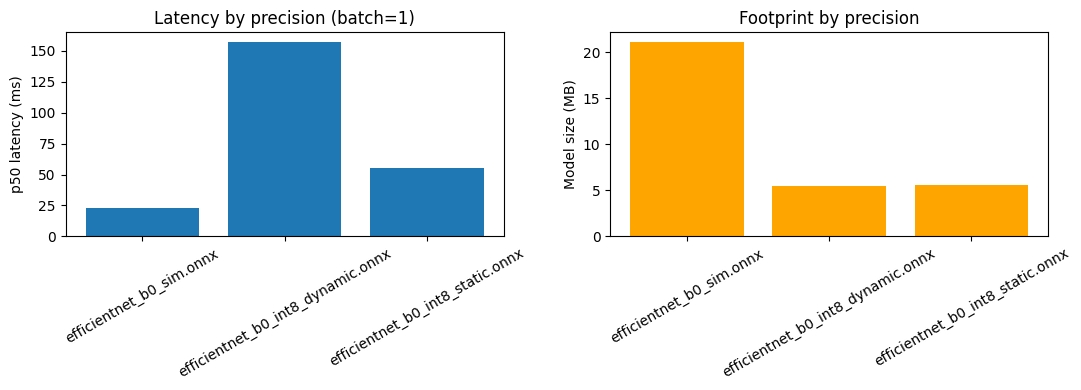

In [ ]:
# Visualise the latency vs file-size trade-off across precisions at batch=1
import matplotlib.pyplot as plt

bs1 = bench_df[bench_df.batch_size == 1]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(bs1["model"], bs1["p50_ms"])
ax[0].set_ylabel("p50 latency (ms)"); ax[0].set_title("Latency by precision (batch=1)")
ax[0].tick_params(axis="x", rotation=30)

ax[1].bar(bs1["model"], bs1["file_size_MB"], color="orange")
ax[1].set_ylabel("Model size (MB)"); ax[1].set_title("Footprint by precision")
ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


**Objective:** turn the numeric benchmark table into a visual a stakeholder (or student) can absorb in seconds — communicating a latency/size trade-off clearly, especially to a non-technical audience, is itself a production-engineering skill, not just a plotting exercise.

**Result:** two bar charts side by side, letting you visually confirm whether the expected pattern held (e.g. INT8 variants smaller and faster than fp32) at a glance rather than by scanning table rows.

**Advantages:** fast to produce; makes trade-offs and outliers immediately visible; easy to extend with more bars as more variants (TensorRT/OpenVINO rows) get added to `bench_df`.

**Disadvantages:** only plots batch=1, so it silently drops the throughput story the full harness computed; shows p50 only, dropping the tail-latency (p95) information that mattered enough to compute in the previous cell; a chart with no accuracy axis can be visually persuasive toward "just pick the smallest bar," reinforcing the exact latency-only blind spot the notebook calls out earlier.

**Accuracy side of the trade-off (assignment extension):** to make the accuracy axis real,
have students load a small labelled validation set (e.g. 500 ImageNet-V2 or a custom dataset
subset), run each of the three ONNX variants over it, and compute top-1 accuracy alongside the
latency numbers above — e.g. *FP32: 77.1% / 6.2ms, INT8-static: 76.4% / 2.1ms*. That paired
table is the deliverable for objective 2.


## 8. Bonus: magnitude pruning

Pruning removes redundant weights. Unstructured pruning (zeroing individual weights) mainly
shrinks the model on disk after compression and rarely speeds up dense GPU matmuls by itself;
*structured* pruning (removing whole channels/filters) is what actually reduces FLOPs and latency.
We demo both so students see the difference.


In [ ]:
import torch.nn.utils.prune as prune
import copy

pruned_model = copy.deepcopy(model).cpu().eval()

# Unstructured (per-weight) pruning -- shrinks storage, NOT latency on dense GPU kernels
for module in pruned_model.modules():
    if isinstance(module, torch.nn.Conv2d):
        prune.l1_unstructured(module, name="weight", amount=0.3)
        prune.remove(module, "weight")

sparsity = sum((m.weight == 0).sum().item() for m in pruned_model.modules() if isinstance(m, torch.nn.Conv2d))
total = sum(m.weight.numel() for m in pruned_model.modules() if isinstance(m, torch.nn.Conv2d))
print(f"Unstructured sparsity in conv layers: {sparsity/total:.1%}")
print("Note: re-export this pruned model to ONNX + run it through Section 6/7 "
      "to see it does NOT meaningfully speed up dense inference -- the lesson is "
      "'sparsity != speed' unless using structured pruning or sparse-aware runtimes.")


**Objective:** intentionally sets up a common misconception in order to correct it. Many students assume "zeroing 30% of the weights" must make a model faster — this cell is designed to demonstrate why that's false for unstructured pruning on standard hardware/runtimes, an important lesson before someone ships a "pruned" model expecting a latency win that never materializes.

**Result:** a model with a measured sparsity percentage in its conv weights — but, critically, no latency change if this model were benchmarked, because dense GPU kernels still multiply through the zeroed weights instead of skipping them.

**Advantages:** unstructured pruning is simple to apply and *can* reduce on-disk size after compression (zeros compress well); can act as a precursor step toward further techniques (sparse-aware runtimes, structured pruning); doesn't require re-architecting the model.

**Disadvantages:** gives essentially no inference speedup on standard dense kernels — FLOPs are unchanged, only some multiplications become "multiply by zero"; the accuracy cost of zeroing weights (not measured in this cell) is real and needs its own separate evaluation; to get an actual latency benefit you need *structured* pruning (removing whole channels/filters, which does shrink matmul dimensions) or a sparsity-aware runtime — both meaningfully more complex to implement correctly than what's shown here.

## 9. Hardware-accelerated inference: TensorRT & OpenVINO

- **TensorRT** (NVIDIA): compiles the ONNX graph into a hardware-specific engine with kernel
  fusion, layer auto-tuning, and FP16/INT8 kernels tuned for the exact GPU. Biggest wins on
  NVIDIA GPUs/Jetson edge devices.
- **OpenVINO** (Intel): equivalent toolkit for Intel CPUs/iGPUs/VPUs — common in edge deployments
  on Intel-based hardware (retail kiosks, industrial cameras).

Colab's free GPU runtime doesn't ship TensorRT or OpenVINO by default, so below are runnable
**install + compile stubs**. Uncomment to run; expect a few minutes for the TensorRT install/build.


In [ ]:
# --- TensorRT via ONNX Runtime's TensorrtExecutionProvider ---
# Uncomment to actually install/run in this Colab session (adds ~3-5 min):
#
# !pip -q install tensorrt onnxruntime-gpu --extra-index-url https://pypi.nvidia.com
#
# trt_sess = ort.InferenceSession(
#     onnx_path,
#     providers=[
#         ("TensorrtExecutionProvider", {
#             "trt_fp16_enable": True,
#             "trt_engine_cache_enable": True,
#             "trt_engine_cache_path": "./trt_cache",
#         }),
#         "CUDAExecutionProvider",
#     ],
# )
# print(trt_sess.get_providers())
# # First call triggers engine build (slow); subsequent calls use the cached engine (fast).
# trt_sess.run(None, {"input": x_np})

print("TensorRT EP stub ready -- uncomment the block above on a CUDA-enabled runtime to build "
      "and benchmark a real TensorRT engine, then add its result row to bench_df in Section 7.")


**Objective:** show students the next rung of the latency-optimization ladder — compiler-level, hardware-specific kernel fusion and autotuning — beyond what generic ONNX Runtime + INT8 quantization already achieved, without forcing every student to pay the multi-minute install cost just to read the code.

**Result (if run):** a compiled, GPU-specific inference engine, typically meaningfully faster than plain ONNX Runtime CUDA execution for the same graph — nothing is actually measured in this run since the cell is left as a stub.

**Advantages:** often the largest latency win available on NVIDIA GPUs, via kernel fusion, per-layer auto-tuning, and native FP16/INT8 kernels tuned to the exact GPU model; engine caching means the (slow) compile cost is paid once, not per-request.

**Disadvantages:** the compiled engine is tied to the specific GPU architecture and TensorRT version it was built on — not portable the way plain ONNX is, so it must be rebuilt per deployment target; first-run compile latency can be minutes, which complicates deployment pipelines (it needs to be a build step, not a runtime step); adds an extra toolchain dependency and version-compatibility burden on top of plain ONNX Runtime.

In [ ]:
# --- OpenVINO (Intel CPU/iGPU) ---
# Uncomment on a CPU runtime (Runtime > Change runtime type > CPU) since OpenVINO targets Intel HW:
#
# !pip -q install onnxruntime-openvino openvino
#
# ov_sess = ort.InferenceSession(
#     onnx_path,
#     providers=[("OpenVINOExecutionProvider", {"device_type": "CPU_FP32"})],
# )
# print(ov_sess.get_providers())

print("OpenVINO EP stub ready -- best demoed on a CPU runtime (it targets Intel CPUs/VPUs, "
      "the common case for edge cameras/kiosks rather than NVIDIA-GPU clouds).")


**Objective:** show the Intel-hardware equivalent of the TensorRT lesson above — which acceleration toolkit to use is a hardware-dependent decision (NVIDIA GPU → TensorRT, Intel CPU/iGPU/VPU → OpenVINO). This connects directly to the edge-deployment discussion prompt: a Raspberry Pi-class device is far more likely to have OpenVINO-relevant Intel hardware, or no dedicated accelerator at all, than an NVIDIA GPU.

**Result (if run on the right hardware):** a session using Intel-tuned CPU/VPU kernels, typically faster than default ONNX Runtime CPU execution on Intel hardware — not measured here since Colab's GPU runtime is the wrong target for it.

**Advantages:** unlocks meaningful CPU/edge-device speedups on Intel hardware without needing a GPU at all — directly relevant to CPU-only edge deployments like an Intel NUC or industrial camera; complements, rather than competes with, GPU-side optimizations.

**Disadvantages:** only helps on Intel hardware — no benefit (and added complexity) on NVIDIA GPU or ARM-based deployments (e.g. Raspberry Pi's Broadcom/ARM SoC); like TensorRT, it's an additional toolchain and dependency to install, validate, and keep in version-lockstep with the rest of the serving stack.

**Classroom takeaway:** TensorRT/OpenVINO sit *after* ONNX export and *alongside*
quantisation — they're compilers that fuse ops and pick hardware-tuned kernels, often combined
with FP16/INT8 for the largest latency wins. The benchmarking harness in Section 7 is exactly
what you'd extend with a `trt_sess`/`ov_sess` row to make the comparison apples-to-apples.


## 10. Serving architecture patterns

### A. ONNX Runtime REST API (lightweight microservice)
A minimal FastAPI wrapper around the `InferenceSession` from Section 5 — appropriate for a
single-model service, low-to-moderate QPS, simple ops.


In [ ]:
rest_api_code = '''
# save as app.py, run with: uvicorn app:app --host 0.0.0.0 --port 8000
from fastapi import FastAPI, UploadFile
import onnxruntime as ort
import numpy as np
from PIL import Image
import io

app = FastAPI()
sess = ort.InferenceSession("efficientnet_b0_int8_static.onnx",
                             providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name

def preprocess(img: Image.Image) -> np.ndarray:
    img = img.resize((224, 224)).convert("RGB")
    x = (np.asarray(img).astype(np.float32) / 255.0 - 0.485) / 0.229
    return x.transpose(2, 0, 1)[None, ...].astype(np.float32)

@app.post("/predict")
async def predict(file: UploadFile):
    img = Image.open(io.BytesIO(await file.read()))
    logits = sess.run(None, {input_name: preprocess(img)})[0]
    return {"class_id": int(logits.argmax()), "confidence": float(logits.max())}
'''
print(rest_api_code)


**Objective:** show the simplest possible way to turn an offline benchmark artifact into something a real client can call over the network — the "minimal viable service" pattern, appropriate for low-to-moderate traffic, single-model deployments, and a useful baseline before reaching for heavier infrastructure like Triton.

**Result:** a printed reference implementation, not a running service — students are expected to copy it into `app.py` and run it themselves with `uvicorn` to see an actual HTTP inference endpoint.

**Advantages:** minimal, easy to read/understand/debug end-to-end; no extra infrastructure required (no model-repository config, no separate server binary) — just Python and a web framework most students already know; fast to stand up for a prototype or an internal single-model tool.

**Disadvantages:** no built-in dynamic batching, multi-model support, GPU-sharing, or metrics — under real concurrent load, each request is handled independently, wasting GPU throughput compared to Triton's batching; scaling this pattern to production traffic means hand-rolling concurrency control, batching, and observability that Triton provides out of the box; a single `InferenceSession` shared across concurrent requests can also become a bottleneck or thread-safety concern depending on how it's deployed.

### B. NVIDIA Triton Inference Server (production-grade multi-model serving)
Appropriate when you need: multiple models/versions, dynamic batching, concurrent model
execution across GPUs, gRPC+HTTP, built-in metrics. Triton just needs a model repository folder
with a `config.pbtxt` — no custom server code to write or maintain.


In [ ]:
triton_config = '''
# model_repository/efficientnet_b0/config.pbtxt
name: "efficientnet_b0"
platform: "onnxruntime_onnx"
max_batch_size: 32
input [
  { name: "input", data_type: TYPE_FP32, dims: [3, 224, 224] }
]
output [
  { name: "logits", data_type: TYPE_FP32, dims: [1000] }
]
dynamic_batching {
  preferred_batch_size: [8, 16, 32]
  max_queue_delay_microseconds: 5000
}
instance_group [
  { count: 2, kind: KIND_GPU }
]
'''
print(triton_config)
print("\nDirectory layout expected by Triton:")
print("model_repository/efficientnet_b0/1/model.onnx")
print("model_repository/efficientnet_b0/config.pbtxt")
print("\nLaunch: docker run --gpus=all -p8000:8000 -p8001:8001 -p8002:8002 \\")
print("  -v$(pwd)/model_repository:/models nvcr.io/nvidia/tritonserver:24.05-py3 \\")
print("  tritonserver --model-repository=/models")


**Objective:** show the production-grade alternative to the hand-rolled FastAPI service — appropriate once traffic, model count, or performance requirements outgrow what a simple REST wrapper can efficiently handle, and demonstrates the specific mechanism (dynamic batching) that lets a shared GPU serve far more throughput than one-request-at-a-time handling.

**Result:** a printed reference `config.pbtxt` plus the commands to actually launch Triton against it — nothing runs inside this notebook, since this is infrastructure meant to run as a standalone server/container.

**Advantages:** `dynamic_batching` substantially raises GPU utilization and throughput under concurrent load by grouping requests server-side, at the cost of only a small, tunable added latency (`max_queue_delay_microseconds`); supports multiple models/versions, multiple GPU instances, and built-in metrics with no custom server code to write or maintain; works directly against the same ONNX (or TensorRT/OpenVINO) artifacts already produced earlier in the notebook.

**Disadvantages:** meaningfully more operational complexity than the FastAPI option — a Docker/Kubernetes deployment, a model-repository directory convention to maintain, and a new set of concepts (instance groups, batching config, model versioning) to learn; likely overkill for a single low-traffic model, where the added infrastructure cost isn't justified by the throughput gains.

## 11. Edge vs Cloud deployment: design exercise

| Dimension | Edge (e.g. Jetson, mobile, OpenVINO box) | Cloud API (e.g. Triton/ORT on GPU instance) |
|---|---|---|
| **Latency** | Lowest (no network round-trip); bounded by weak local compute | Higher network latency, but stronger compute per request |
| **Cost model** | Upfront hardware cost, no per-inference cloud bill | Pay-per-use/instance-hour; scales with traffic |
| **Scalability** | Fixed per device; scale = ship more devices | Elastic — autoscale GPU pool with demand |
| **Model size budget** | Tight (RAM/storage/power) → favours INT8/pruned small backbones | Looser — can afford larger backbones, batch heavily |
| **Connectivity** | Works offline | Requires network connectivity |
| **Update/rollback** | Harder (fleet OTA updates) | Easy (redeploy a container) |
| **Data privacy** | Data never leaves device | Data transits network/cloud |

### Worked scenario for students to extend
> *"A retail chain wants real-time shelf out-of-stock detection from 5,000 store cameras."*

Guiding questions to assign:
1. Would you run inference at the edge (per-store NUC/Jetson with OpenVINO/TensorRT) or stream
   frames to a cloud Triton cluster? Justify with the cost/latency/scalability table above.
2. Given the latency/accuracy numbers measured in Section 7, which backbone + precision
   combination fits the chosen deployment target?
3. Sketch the request flow: camera → preprocessing → inference → business logic → alerting.
   Where do batching and dynamic batching (Section 10B) help?
4. What's the rollback plan if a newly deployed quantised model regresses accuracy in production?

This question is the deliverable for *"design and document a production CV inference architecture
for a specified industry scenario"* — have students produce a one-page architecture diagram +
written justification referencing the actual benchmark numbers they generated above.
